In [1]:
# CELL 1: Setup
import os
import sys
sys.path.append('..')

import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from configs.config import Config
from data.splits import get_patient_splits
from models.bu_net import BUNet
from data.few_shot_sampler import FewShotSampler, kshot_finetune_eval
from configs.results_utils import save_kshot_results
from configs.model_utils import load_model_weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [2]:
# CELL 2: Load Pretrained Baseline
model = BUNet(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

load_model_weights(model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)

✓ Loaded checkpoint: best_model.pth


True

In [3]:
# CELL 3: Build Few-Shot Samplers
train_ids, val_ids, test_ids = get_patient_splits(Config.TRAIN_DATASET_PATH)

# Use val patients as support, test patients as query
# This avoids any data leakage from training
samplers = {}
for k in Config.K_SHOT_VALUES:
    samplers[k] = FewShotSampler(
        support_ids=val_ids,
        query_ids=test_ids,
        data_path=Config.TRAIN_DATASET_PATH,
        k_shot=k,
        n_query=Config.N_QUERY,
        tumor_only=True,
    )
    print(f"✓ Built sampler for k={k}")

✓ Splits -> Train: 258, Val: 74, Test: 37
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=1
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=5
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=10
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=20


In [4]:
# CELL 4: Run k-Shot Evaluation (Dice + HD95)
results = {}

for k in Config.K_SHOT_VALUES:
    print(f"\n{'='*50}")
    print(f"Evaluating k={k} shot (50 episodes)...")
    print(f"{'='*50}")

    dice_scores, hd95_scores = kshot_finetune_eval(
        pretrained_model=model,
        sampler=samplers[k],
        device=Config.DEVICE,
        lr=1e-4,
        finetune_steps=10,
        n_episodes=50,
        compute_hd95=True,
    )

    results[k] = {
        'mean': float(np.mean(dice_scores)),
        'std': float(np.std(dice_scores)),
        'hd95_mean': float(np.nanmean(hd95_scores)),
        'hd95_std': float(np.nanstd(hd95_scores)),
        'scores': [float(d) for d in dice_scores],
    }

# Print summary
print(f"\n{'='*60}")
print("BASELINE K-SHOT RESULTS")
print(f"{'='*60}")
for k in Config.K_SHOT_VALUES:
    r = results[k]
    print(f"  k={k:>2}: Dice = {r['mean']:.4f} ± {r['std']:.4f}  |  "
          f"HD95 = {r['hd95_mean']:.2f} ± {r['hd95_std']:.2f} px")
print(f"{'='*60}")

save_kshot_results(results, Config.RESULTS_DIR, 'baseline_kshot_results.json')


Evaluating k=1 shot (50 episodes)...
  Episode 10/50 | Dice: 0.5853 | HD95: 18.26 px
  Episode 20/50 | Dice: 0.6096 | HD95: 17.35 px
  Episode 30/50 | Dice: 0.6094 | HD95: 17.81 px
  Episode 40/50 | Dice: 0.5970 | HD95: 19.89 px
  Episode 50/50 | Dice: 0.5947 | HD95: 20.41 px

k=1 shot | Dice: 0.5947 ± 0.1375
  HD95: 20.41 ± 15.51 px

Evaluating k=5 shot (50 episodes)...
  Episode 10/50 | Dice: 0.7007 | HD95: 4.71 px
  Episode 20/50 | Dice: 0.7136 | HD95: 4.23 px
  Episode 30/50 | Dice: 0.7321 | HD95: 3.98 px
  Episode 40/50 | Dice: 0.7321 | HD95: 4.07 px
  Episode 50/50 | Dice: 0.7320 | HD95: 4.03 px

k=5 shot | Dice: 0.7320 ± 0.0831
  HD95: 4.03 ± 2.82 px

Evaluating k=10 shot (50 episodes)...
  Episode 10/50 | Dice: 0.7085 | HD95: 2.93 px
  Episode 20/50 | Dice: 0.7328 | HD95: 2.92 px
  Episode 30/50 | Dice: 0.7319 | HD95: 3.21 px
  Episode 40/50 | Dice: 0.7318 | HD95: 3.12 px
  Episode 50/50 | Dice: 0.7361 | HD95: 3.08 px

k=10 shot | Dice: 0.7361 ± 0.0778
  HD95: 3.08 ± 1.05 px



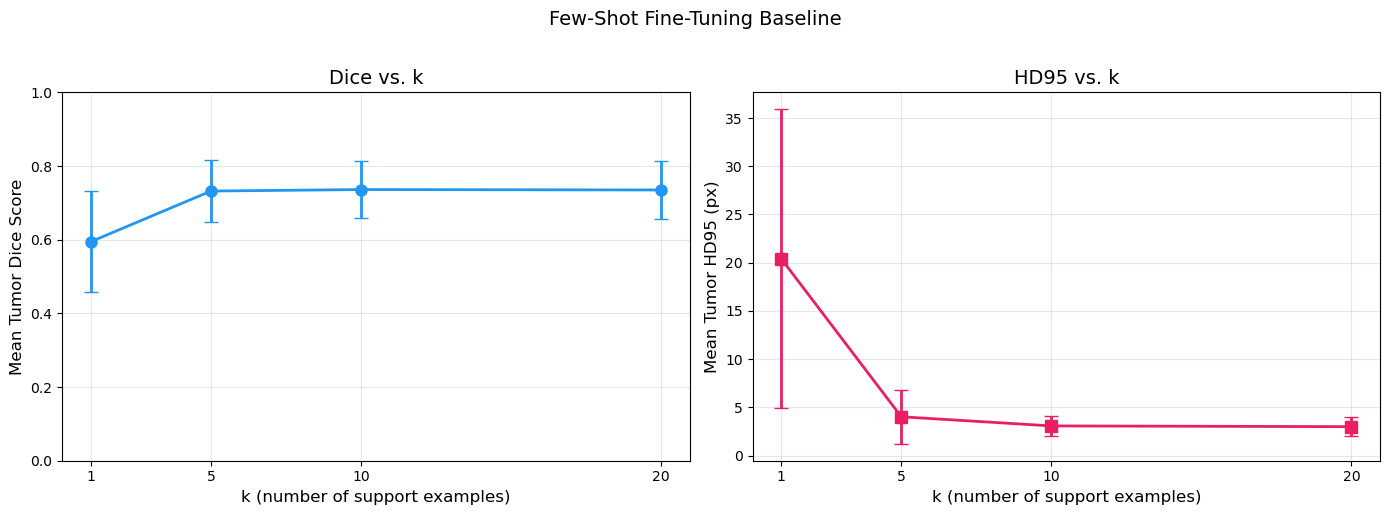

In [5]:
# CELL 5: K-Shot Learning Curves (Dice + HD95)
k_values = Config.K_SHOT_VALUES
means = [results[k]['mean'] for k in k_values]
stds = [results[k]['std'] for k in k_values]
hd_means = [results[k]['hd95_mean'] for k in k_values]
hd_stds = [results[k]['hd95_std'] for k in k_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dice curve
ax1.errorbar(k_values, means, yerr=stds, marker='o', capsize=5,
             linewidth=2, markersize=8, color='#2196F3')
ax1.set_xlabel('k (number of support examples)', fontsize=12)
ax1.set_ylabel('Mean Tumor Dice Score', fontsize=12)
ax1.set_title('Dice vs. k', fontsize=14)
ax1.set_xticks(k_values)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# HD95 curve
ax2.errorbar(k_values, hd_means, yerr=hd_stds, marker='s', capsize=5,
             linewidth=2, markersize=8, color='#E91E63')
ax2.set_xlabel('k (number of support examples)', fontsize=12)
ax2.set_ylabel('Mean Tumor HD95 (px)', fontsize=12)
ax2.set_title('HD95 vs. k', fontsize=14)
ax2.set_xticks(k_values)
ax2.grid(True, alpha=0.3)

plt.suptitle('Few-Shot Fine-Tuning Baseline', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'baseline_kshot_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()